Epoch 1, Loss: 189.9025
Epoch 2, Loss: 167.6574
Epoch 3, Loss: 163.5682
Epoch 4, Loss: 161.3709
Epoch 5, Loss: 159.7860


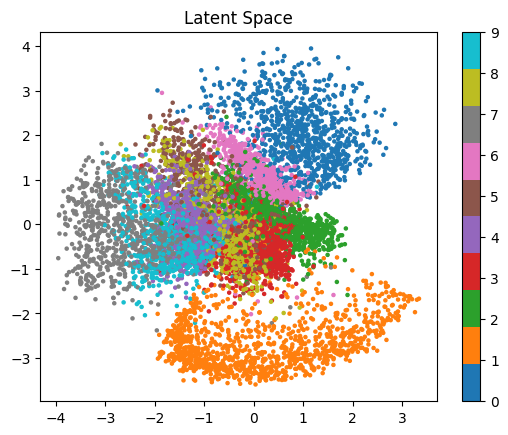

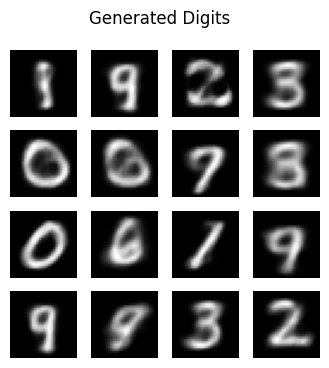

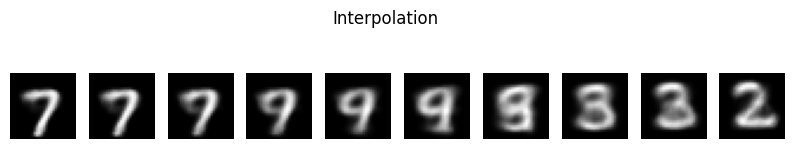

In [2]:
# =========================
# VAE on MNIST (COLAB READY)
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# DATA
# =========================
transform = transforms.ToTensor()

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=False, transform=transform),
    batch_size=128, shuffle=False)

# =========================
# MODEL
# =========================
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(28*28, 400)
        self.fc_mu = nn.Linear(400, 2)
        self.fc_logvar = nn.Linear(400, 2)

        self.fc2 = nn.Linear(2, 400)
        self.fc3 = nn.Linear(400, 28*28)

    def encode(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc_mu(x), self.fc_logvar(x)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        z = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# =========================
# LOSS
# =========================
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KL

# =========================
# TRAIN
# =========================
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, _ in train_loader:
        x = x.view(-1, 28*28).to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss = loss_function(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader.dataset):.4f}")

# =========================
# LATENT SPACE VISUALIZATION
# =========================
model.eval()
z_list = []
labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.view(-1, 28*28).to(device)
        mu, _ = model.encode(x)
        z_list.append(mu.cpu())
        labels.append(y)

z = torch.cat(z_list)
labels = torch.cat(labels)

plt.figure()
plt.scatter(z[:,0], z[:,1], c=labels, cmap='tab10', s=5)
plt.colorbar()
plt.title("Latent Space")
plt.show()

# =========================
# GENERATION
# =========================
with torch.no_grad():
    z = torch.randn(16, 2).to(device)
    samples = model.decode(z).cpu()

plt.figure(figsize=(4,4))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i].view(28,28), cmap='gray')
    plt.axis('off')
plt.suptitle("Generated Digits")
plt.show()

# =========================
# INTERPOLATION
# =========================
data_iter = iter(test_loader)
images, _ = next(data_iter)

x1 = images[0].view(-1,28*28).to(device)
x2 = images[1].view(-1,28*28).to(device)

with torch.no_grad():
    z1, _ = model.encode(x1)
    z2, _ = model.encode(x2)

steps = 10
z_interp = [(1-t)*z1 + t*z2 for t in torch.linspace(0,1,steps)]

plt.figure(figsize=(10,2))
for i, z in enumerate(z_interp):
    img = model.decode(z).cpu().detach() # Added .detach() here
    plt.subplot(1,steps,i+1)
    plt.imshow(img.view(28,28), cmap='gray')
    plt.axis('off')

plt.suptitle("Interpolation")
plt.show()